### Build W-State in QpiAI Explorer Lab on Amazon Braket

In this tutorial, we will learn about creating and running a W-state circuit using braket on QpiAI Explorer Lab

In [1]:
#install amazon braket
%pip install amazon-braket-sdk


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.7/313.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.0/224.0 kB 11.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.7/191.7 kB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 15.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.8/539.8 kB 12.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 9.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 9.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 kB 3.3 MB/s eta 0:00:00
  Created wheel for antlr4-python3-runtime: filename=antlr4_python3_runtime-4.9.2-py3-none-any.whl size=144548 sha256=28a43092c4c0b6b60f1bc5

In [2]:
#import general functions
import numpy as np

#import relevant braket functions
from braket.circuits import Circuit
from braket.devices import LocalSimulator

### Build a W-state circuit

A W-state is an entangled three qubit quantum state constituting the equally weighted superposition of the states |001>, |010>, and |100>.

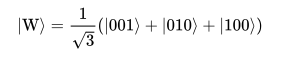

The circuit to create the W-state that consists of an Ry rotation, followed by a controlled Hadamard, 2 CX gates and an X gate. The angle of Ry rotation is 2*arccos(1/√3)

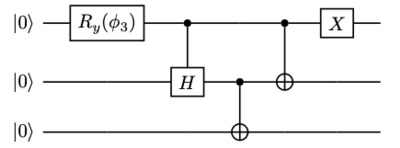

Since the controlled Hadamard gate can be decomposed further into two single qubit Ry rotations of angle π/4 and a two qubit CNOT gate in between.






In [3]:
#circuit to create a W-state

def create_w_state():

  circuit = Circuit()

  #apply y-rotation on control qubit 0 to create superposition of |0> and |1>
  phi = 2*np.arccos(1/np.sqrt(3))
  circuit.ry(0,phi)

  #controlled Hadamard with control qubit 0 and target qubit 1

  circuit.ry(1,np.pi/4)
  circuit.cnot(control = 0, target = 1)
  circuit.ry(1,-np.pi/4)

  #apply controlled hadamard with control qubit 0 and target qubit 1


  #apply CNOT gate on all subsequent pair of qubits to create the W-state
  circuit.cnot(control = 1, target = 2)
  circuit.cnot(control = 0, target = 1)

  #apply the not gate on the control qubit 0
  circuit.x(0)

  return circuit

#test the w-state circuit

w_state = create_w_state()

### Test the W State circuit

In [4]:
# set up device
device = LocalSimulator()

In [5]:
# run circuit
result = device.run(w_state, shots=1000).result()

# get measurement shots
counts = result.measurement_counts

# print counts
print(counts)

Counter({'010': 347, '001': 330, '100': 323})


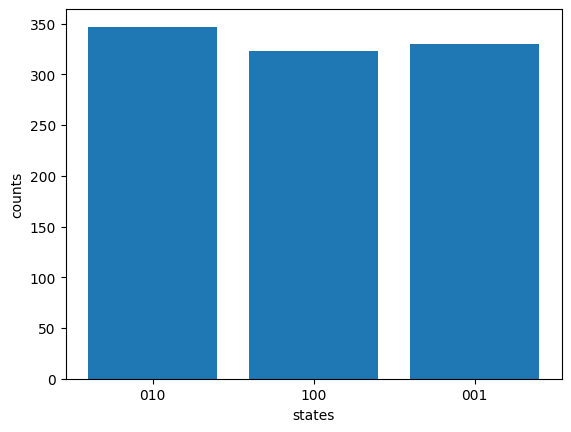

In [6]:
import matplotlib.pyplot as plt

# plot using Counter

plt.bar(counts.keys(), counts.values())
plt.xlabel('states')
plt.ylabel('counts')
plt.show()